# Introduction to Data Science - Homework 3
*COMP 5360 / MATH 4100, University of Utah, http://datasciencecourse.net/*

Due: Friday, January 30, 11:59pm.

In this homework you will read in and analyze a games dataset. First we'll do some basic analysis with vanilla Python, then we'll move on to doing more advanced analysis with [Pandas](http://pandas.pydata.org/pandas-docs/stable). 


## Your Data
Fill out the following information: 

*First Name:*   Ibrahim
*Last Name:*   Ergin
*E-mail:*   u1564808@utah.edu
*UID:*  u1564808


In [1]:
# imports
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

## Part 1: Analyzing Data The Basic Way

In this part we'll do some manual analysis of an Iphone Strategy Games dataset.

### Task 1.1: Read in the data

Parse the file [games.csv](games.csv) using the [csv library](https://docs.python.org/3/library/csv.html). Lecture 6 and might be a good inspiration for this. 

We recommend that you store the header in a separate array. Make sure that at least the "Rating" and the "Number of Ratings" columns are cast to the appropriate data types for doing calculations with them. 

Print the header, the number of rows and columns, and Row 50 of the table.

In [2]:
# initialize  arrays
games = []
header = []
ratings = []
number_of_ratings = []
genres = []

with open('games.csv',newline='') as csvfile:
    csv_reader = csv.reader(csvfile, delimiter=',')
    header = next(csv_reader) # reads the first row which is header in our dataset.
    for row in csv_reader:
        games.append(row[0])
        ratings.append(float(row[3]))
        number_of_ratings.append(int(row[4]))
        genres.append(row[9])



print(f"Headers are: {header}")
print(f"Number of rows: {len(games)}")
print(f"Number of columns: {len(header)}")


Headers are: ['App Name', 'App ID', 'Price', 'Rating', 'Number of Ratings', 'Developer', 'Size', 'Minimum OS Version', 'Content Rating', 'Genre', 'Year']
Number of rows: 15668
Number of columns: 11


In [3]:
with open('games.csv',newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    header = next(reader) # reads the first row which is header in our dataset.
    for i, row in enumerate(reader):
        if i > 49:
            break
        print(f"{str(i+1)}.{row}")
        

1.['Boom Beach: War Strategy Game', '672150402', 'Free', '4.70967', '287246', 'Supercell Oy', '604057600', '12', '9+', 'Action', '2014']
2.['State.io - Conquer the World', '1559032748', 'Free', '4.54875', '198271', 'AI GAMES FZ LLC', '274869248', '13', '12+', 'Strategy', '2021']
3.['Two Spies', '1466304408', 'Free', '4.74081', '11235', 'Royal Pixel Service, Ltd.', '92142592', '13', '9+', 'Board', '2019']
4.['Forge of Empires: Build a City', '711455226', 'Free', '4.60095', '164179', 'InnoGames GmbH', '388532224', '12', '9+', 'Entertainment', '2014']
5.['Clash of Clans', '529479190', 'Free', '4.75467', '2571858', 'Supercell Oy', '420755456', '12', '9+', 'Action', '2012']
6.['Stick War: Legacy', '1001780528', 'Free', '4.80455', '61684', '1004319 Alberta Ltd', '260213760', '13', '12+', 'Adventure', '2016']
7.['T3 Arena', '1602814337', 'Free', '4.77987', '79070', 'XD Entertainment Pte Ltd', '2150713344', '12', '9+', 'Action', '2022']
8.['Clash Royale', '1053012308', 'Free', '4.5875', '28183

https://www.geeksforgeeks.org/python/get-column-names-from-csv-using-python/

### Task 1.2:  Calculate game stats

In this task, you will calculate some statistics about games. We suggest you implement your solutions for Tasks 1.2.1-1.2.3 in one code cell – you should be able to calculate this in a single iteration over the dataset.

#### Task 1.2.1 Calcualte average ratings
Compute the average rating for all games and print the output and total. Your output could look like this:
    
    Average rating: xxx.xxxx, Total games: xx

#### Task 1.2.2: Calculate average rating for major games

Compute the average rating for the games that have more than 200 ratings in your loaded dataset and print the output. (We'll call these games with more than 200 ratings major games from now on).

Your output could look like this:
    
    Average rating for major games: xxx.xxxx, Total major games: xx

#### Task 1.2.3: Find the highest and the lowest rated major games, and determine how many ratings they have

Determine which major game has the highest rating and which has the lowest rating.

Your output could look like this:
    
    Highest rating: xxx.xxxx, Title: GAME TITLE, Number of Ratings: xxxx 
    Lowest rating: xxx.xxxx, Title: GAME TITLE, Number of Ratings: xxxx 
 
#### Task 1.2.4: Interpret the data
 * What's the rating relationship of major games to all games?
 * Are major games typically better than the average of all games?
 * Are particular genres rated higher than others?

In [4]:
def calculate_game_stats(games, ratings, number_of_ratings, genres):
    total_rating = 0.0
    total_games = len(games)
    
    total_major_rating = 0.0
    total_major_games = 0
    
    highest_rating = -1
    lowest_rating = 6
    highest_game_title = ""
    lowest_game_title = ""
    highest_game_num_ratings = 0
    lowest_game_num_ratings = 0
    
    genre_total_ratings = {}
    genre_game_counts = {}
    
    for i in range(len(games)):
        total_rating += ratings[i]
        
        if genres[i] in genre_total_ratings:
            genre_total_ratings[genres[i]] += ratings[i]
            genre_game_counts[genres[i]] += 1
        else:
            genre_total_ratings[genres[i]] = ratings[i]
            genre_game_counts[genres[i]] = 1
        
        if number_of_ratings[i] > 200:
            total_major_rating += ratings[i]
            total_major_games += 1
            
            if ratings[i] > highest_rating:
                highest_rating = ratings[i]
                highest_game_title = games[i]
                highest_game_num_ratings = number_of_ratings[i]
            
            if ratings[i] < lowest_rating:
                lowest_rating = ratings[i]
                lowest_game_title = games[i]
                lowest_game_num_ratings = number_of_ratings[i]
    
    avg_rating = total_rating / total_games
    avg_major_rating = total_major_rating / total_major_games
    
    genre_avg_ratings = {}
    for genre in genre_total_ratings:
        genre_avg_ratings[genre] = genre_total_ratings[genre] / genre_game_counts[genre]
    
    return (avg_rating, total_games, avg_major_rating, total_major_games,
            highest_rating, highest_game_title, highest_game_num_ratings,
            lowest_rating, lowest_game_title, lowest_game_num_ratings,
            genre_avg_ratings, genre_game_counts)


# ALL data
results = calculate_game_stats(games, ratings, number_of_ratings, genres)

# task 1.2.1
print(f"Average rating: {results[0]:.4f}, Total games: {results[1]}")

# task 1.2.2
print(f"Average rating for major games: {results[2]:.4f}, Total major games: {results[3]}")

# task 1.2.3
print(f"Highest rating: {results[4]:.4f}, Title: {results[5]}, Number of Ratings: {results[6]}")
print(f"Lowest rating: {results[7]:.4f}, Title: {results[8]}, Number of Ratings: {results[9]}")

# task 1.2.4
genre_avg_ratings = results[10]
genre_game_counts = results[11]

sorted_genres = sorted(genre_avg_ratings.items(), key=lambda x: x[1], reverse=True)

print("\nTop 5 Genres by Rating:")
for genre, avg in sorted_genres[:5]:
    print(f"{genre}: {avg:.4f} (n={genre_game_counts[genre]})")

print("\nBottom 5 Genres by Rating:")
for genre, avg in sorted_genres[-5:]:
    print(f"{genre}: {avg:.4f} (n={genre_game_counts[genre]})")

Average rating: 2.8902, Total games: 15668
Average rating for major games: 4.5066, Total major games: 2692
Highest rating: 4.9916, Title: Crazy Rolling Hero, Number of Ratings: 358
Lowest rating: 1.5889, Title: Three Kingdoms Killing, Number of Ratings: 995

Top 5 Genres by Rating:
Developer Tools: 4.8281 (n=2)
Magazines & Newspapers: 4.3415 (n=1)
Photo & Video: 3.8537 (n=5)
Finance: 3.6858 (n=12)
Social Networking: 3.6001 (n=41)

Bottom 5 Genres by Rating:
News: 1.3571 (n=2)
Shopping: 1.2222 (n=3)
Navigation: 1.0000 (n=1)
Medical: 0.0000 (n=1)
Animals & Nature: 0.0000 (n=1)


**Your Interpretation**: 

Major games show a significant positive rating bias with an average of 4.5066 compared to 2.8902 for all games. This 1.6164 point difference suggests that popular games tend to be higher quality. "Crazy Rolling Hero" leads with 4.9916 (358 ratings) while "Three Kingdoms Killing" is lowest at 1.5889 (995 ratings).
When examining genres, Developer Tools (4.8281) is the highest rated while Animal & Nature (0.0000) and Medical (0.0000) are the lowest. However, these genres have very small sample sizes (n=1), making comparisons less reliable.

## Part 2: Pandas

In this part we will use the [Pandas library](http://pandas.pydata.org/pandas-docs/stable) for our analysis.

### Task 2.1: Loading data

Read in the data again. This time you should create a [Pandas DataFrame](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.html). Print the head of the dataset. 
 * How many data rows did you load? How many columns?
 * Of which data types are the columns? 
 * Do you have to do manual data type conversions?

In [5]:
df = pd.read_csv("games.csv", delimiter=",")
print("How many data rows did you load? How many columns?")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# shows data types of the columns

print("\nWhich data types are the columns?")
print(df.dtypes)

# check what is inside the price column
print("\nDo you have to do manual data type conversions?")
print(df['Price'].unique())
print("\nYes!")


# convert price to numeric variable(Free ==> 0, remove '$' sign)
df['Price'] = df['Price'].replace('Free', '0.00')
df['Price'] = df['Price'].str.replace('$', '')
df['Price'] = pd.to_numeric(df['Price'])

# verify the conversion
df['Price']

How many data rows did you load? How many columns?
Rows: 15668, Columns: 11

Which data types are the columns?
App Name               object
App ID                  int64
Price                  object
Rating                float64
Number of Ratings       int64
Developer              object
Size                    int64
Minimum OS Version     object
Content Rating         object
Genre                  object
Year                    int64
dtype: object

Do you have to do manual data type conversions?
['Free' '$0.99 ' '$6.99 ' '$2.99 ' '$9.99 ' '$1.99 ' '$4.99 ' '$3.99 '
 '$14.99 ' '$5.99 ' '$19.99 ' '$8.99 ' '$7.99 ' '$11.99 ' '$12.99 '
 '$10.99 ' '$3.49 ' '$0.29 ' '$16.99 ' '$1.49 ' '$24.99 ' '$0.49 '
 '$18.99 ' '$9.49 ' '$29.99 ' '$2.69 ' '$8.95 ' '$2.49 ' '$39.99 '
 '$0.79 ' '$299.99 ' '$149.99 ' '$399.99 ']

Yes!


0        0.00
1        0.00
2        0.00
3        0.00
4        0.00
         ... 
15663    0.00
15664    1.99
15665    2.99
15666    0.00
15667    0.99
Name: Price, Length: 15668, dtype: float64

**Your Interpretation**: 

When I check type of columns, price column was object but it suppose to be float. So I have to convert it into float. But there were "Free" as a value and "$" sign so i have to convert or remove those. Then I convert to the float type.

### Task 2.2: Calculate the average rating

Compute the average rating and price (rounded to the nearest cent) for all games and print the output and total. Your output could look like this:
    
    Average rating: xxx.xxxx, Average price: xx.xx, Total games: xx

In [6]:
avg_rating = df['Rating'].mean()
avg_price = df['Price'].mean()
total_games = len(df)

print(f"Average rating: {avg_rating:.4f}, Average price: {avg_price:.2f}, Total games: {total_games}")

Average rating: 2.8902, Average price: 0.45, Total games: 15668


### Task 2.3: Compare the runtime

We want to measure how long it takes to calculate the average using Pandas versus using a for loop (you can copy the relevant parts from Task 1). This is a fast calculation, so running once is not enough. Instead, run both calcuations 1000 times (in a loop) and measure the time for the entire loop.

To measure, use [time.process_time()](https://docs.python.org/3/library/time.html#time.process_time) to collect timestamps before and after the loop. The total time is the difference between those timestamps.

Print your results in a human readable way and add a metric to the output. Calculate the factor of the difference and print it. Note that the exact times and the factors will vary when you re-run this and especially between machines. 

E.g.:  
 Time the Part 1 way: xxx.xxx s\
 Time using Pandas: xxx.xxx s\
 Difference factor: xxx
    
Interpret the results. Is this difference substantial?     

In [7]:
import time

# for loop
start_time = time.process_time()

for _ in range(1000):
    total_rating = 0.0
    total_games = len(games)
    for i in range(len(games)):
        total_rating += ratings[i]
    avg_rating_loop = total_rating / total_games

end_time = time.process_time()
loop_time = end_time - start_time

# pandas
start_time = time.process_time()

for _ in range(1000):
    avg_rating_pandas = df['Rating'].mean()

end_time = time.process_time()
pandas_time = end_time - start_time

# results
difference_factor = loop_time / pandas_time

print(f"Time for loop: {loop_time:.3f} s")
print(f"Time using Pandas: {pandas_time:.3f} s")
print(f"Difference factor: {difference_factor:.1f}")

Time for loop: 0.922 s
Time using Pandas: 0.016 s
Difference factor: 59.0


**Your Interpretation**: 

The Pandas method is significantly faster than the for loop approach. Pandas completed 1000 calculations in approximately 0.016 seconds, while the for loop took 0.922 seconds. This difference is substantial because Pandas uses optimized C-based operations under the hood, whereas Python for loops have overhead for each iteration. For large datasets like this (15,668 rows), Pandas' vectorized operations provide a major performance advantage.

### Task 2.4: Filter out Rows

The whole games dataset has about 15,000 games. Use pandas to filter your dataframe to contain only the major games. Then print the total.

E.g.:
    xxx.xxx games have more than 200 ratings.

In [8]:
major_games_df = df[df["Number of Ratings"] > 200].copy()

print(f"{major_games_df.shape[0]} games have more than 200 ratings.")

2692 games have more than 200 ratings.


### Task 2.5: Calculate the average rating and price for major games

Compute the average rating and price (rounded to the nearest cent) for the major games.
Your output could look like this:
    
    Average rating of major games: xxxx.xxx, Average price of major games: xxx.xx

In [19]:
#calculate averages
avg_rating = major_games_df['Rating'].mean()
avg_price = major_games_df['Price'].mean()

print(f"Average rating of major games: {avg_rating:.3f}, Average price of major games: {avg_price:.3f}")

Average rating of major games: 4.507, Average price of major games: 0.421


### Task 2.6: Find the highest and lowest rated major games

Find the highest rated major game and the lowest major game in the dataframe. Hint: [idxmax()](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.idxmax.html) and [idxmin()](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.idxmin.html) could be helpful, or you could sort by rating and retrieve the first element.

Print the title and the rating.

Your output could look like this:
    
    Highest rated game: TITLE, rating: x.x
    Lowest rated game: TITLE, rating: x.x


In [10]:
# get index of highest and lowest rated games
highest_idx = major_games_df['Rating'].idxmax()
lowest_idx = major_games_df['Rating'].idxmin()

# get the game details
highest_game = major_games_df.loc[highest_idx]
lowest_game = major_games_df.loc[lowest_idx]

print(f"Highest rated game: {highest_game['App Name']}, rating: {highest_game['Rating']:.1f}")
print(f"Lowest rated game: {lowest_game['App Name']}, rating: {lowest_game['Rating']:.1f}")

Highest rated game: Crazy Rolling Hero, rating: 5.0
Lowest rated game: Three Kingdoms Killing, rating: 1.6


### Task 2.7: Create genre subset frames

From the major games you filtered out in a previous task, find out 
 * How many are Action.
 * How many are Adventure.
 * How many are both Action and Adventure.
 
Create new dataframes for each of these subsets.

Hint: you can combine broadcasting statements with a boolean and using the `&` operator.

Print the results, e.g.:  

    xxx.xxx major games are Action.
    xxx.xxx major games are Adventure .
    xxx.xxx major games are both, Action and Adventure.

In [11]:
# action games
action_df = major_games_df[major_games_df['Genre'] == 'Action']

# adventure games
adventure_df = major_games_df[major_games_df['Genre'] == 'Adventure']

# both action and adventure (using & operator)
action_adventure_df = major_games_df[(major_games_df['Genre'] == 'Action') & (major_games_df['Genre'] == 'Adventure')]

print(f"{len(action_df)} major games are Action.")
print(f"{len(adventure_df)} major games are Adventure.")
print(f"{len(action_adventure_df)} major games are both, Action and Adventure.")

137 major games are Action.
38 major games are Adventure.
0 major games are both, Action and Adventure.


### Task 2.8: Compare ratings of different categories

Now we want to compare the ratings for Action and Adventure among the major games.

Compute the average rating, maximum rating, minimum rating, standard deviation, and the median for each category. Hint: there is a function that does all of this in one line. 

What do these numbers tell us? Provide an interpretation.

In [12]:
# comparison dataframe
comparison = pd.DataFrame({
    'Action': action_df['Rating'].describe(),
    'Adventure': adventure_df['Rating'].describe()
})

print(comparison)

           Action  Adventure
count  137.000000  38.000000
mean     4.467734   4.418819
std      0.364884   0.372384
min      2.567040   2.782920
25%      4.333760   4.269312
50%      4.558680   4.476810
75%      4.697280   4.668415
max      4.897910   4.864200


**Your Interpretation**: 
Action games have a slightly higher average rating (4.47) than Adventure games (4.42). Both genres show similar variability (std ~0.36-0.37) and maximum ratings (~4.9). Action has more ratings (137) compared to Adventure (38), making it a more reliable comparison. The similar medians (4.56 vs 4.48) suggest both genres maintain consistent quality among popular titles.

### Task 2.9: Major games over time

Calculate how many major games in this dataset were made in each year.

Print the number like this, sorted by year:

    year   number of games
    2008    xxx
    2009    xxx
    ...     ...

Use this data to render a line chart of the number of games per year.

In [13]:
# count major games per year using groupby
games_per_year = major_games_df.groupby('Year').size()

# results
print("Year   Number of games")
for year, count in games_per_year.items():
    print(f"{year}    {count}")



Year   Number of games
2008    5
2009    30
2010    35
2011    39
2012    76
2013    108
2014    111
2015    159
2016    229
2017    232
2018    250
2019    256
2020    265
2021    241
2022    248
2023    211
2024    195
2025    2


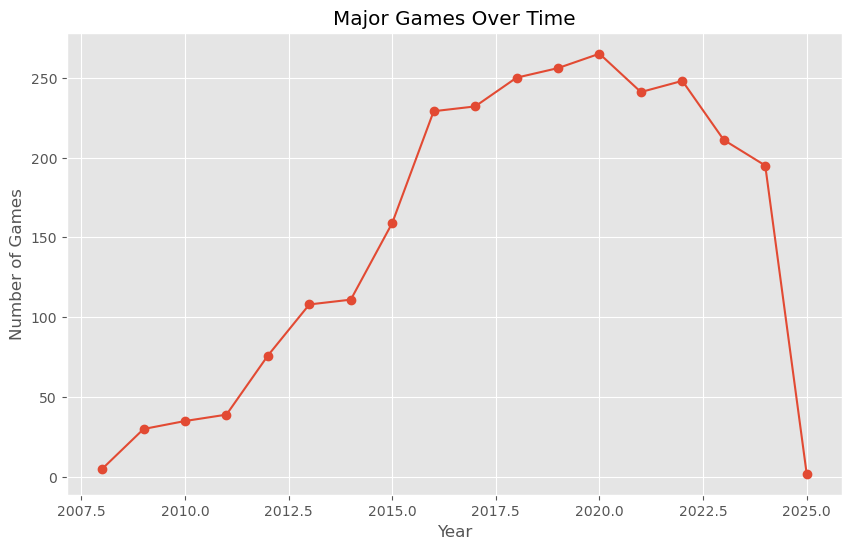

In [14]:
# create the plot
plt.figure(figsize=(10, 6))
plt.plot(games_per_year.index, games_per_year.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.title('Major Games Over Time')
plt.grid(True)
plt.show()

### Task 2.10: Yearly average

Compute the average rating per year for all major games.\
Use the numbers you computed to plot a line chart. Plot the year on x-axis and the average rating on y-axis.  

Year   Average Rating
2008    4.5604
2009    4.3490
2010    4.3227
2011    4.4957
2012    4.4245
2013    4.3784
2014    4.4226
2015    4.4193
2016    4.4314
2017    4.4533
2018    4.4871
2019    4.5333
2020    4.5696
2021    4.4984
2022    4.6099
2023    4.6142
2024    4.6129
2025    3.7309


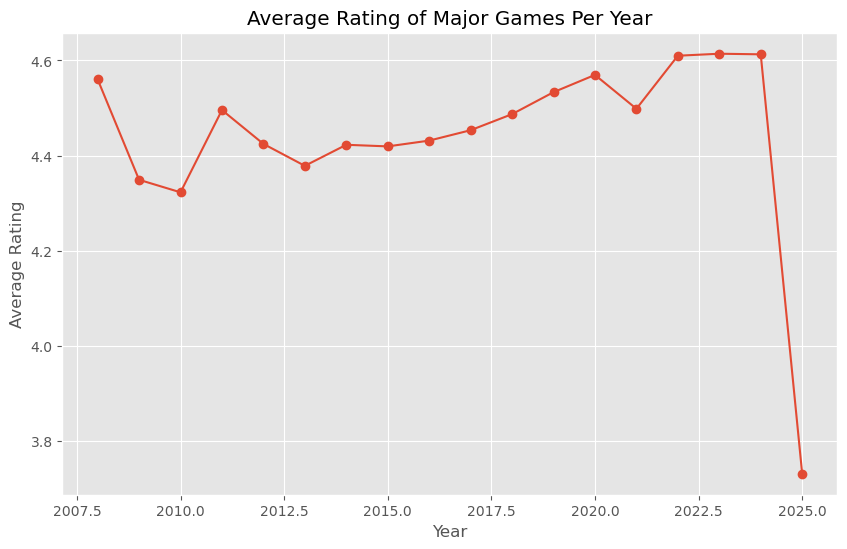

In [15]:
# calculate average rating per year
avg_rating_per_year = major_games_df.groupby('Year')['Rating'].mean()

# results
print("Year   Average Rating")
for year, avg in avg_rating_per_year.items():
    print(f"{year}    {avg:.4f}")

# create the plot
plt.figure(figsize=(10, 6))
plt.plot(avg_rating_per_year.index, avg_rating_per_year.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.title('Average Rating of Major Games Per Year')
plt.grid(True)
plt.show()

### Task 2.11: Free vs Paid

Compare free games against paid games.\
Calculate the average rating and number of ratings between free and paid games. Create a metric to determine popularity using at least these two inputs. Compare the popularity of free games against paid games in each genre using your metric.

In [16]:
# split into free and paid games
free_games_df = major_games_df[major_games_df['Price'] == 0]
paid_games_df = major_games_df[major_games_df['Price'] > 0]

# basic comparison
print("Free Games:")
print(f"Average Rating: {free_games_df['Rating'].mean():.4f}")
print(f"Average Number of Ratings: {free_games_df['Number of Ratings'].mean():.2f}")

print("\nPaid Games:")
print(f"Average Rating: {paid_games_df['Rating'].mean():.4f}")
print(f"Average Number of Ratings: {paid_games_df['Number of Ratings'].mean():.2f}")

# create popularity metric
major_games_df['Popularity'] = major_games_df['Rating'] * np.log10(major_games_df['Number of Ratings'])

# compare by genre using groupby
# I used feature engineering to create a new popularity score from the existing Rating and Number of Ratings columns.
popularity_by_genre = major_games_df.groupby(['Genre', major_games_df['Price'] > 0])['Popularity'].mean()

print("\nPopularity by Genre (Free vs Paid):")
print(popularity_by_genre)

Free Games:
Average Rating: 4.5056
Average Number of Ratings: 16641.49

Paid Games:
Average Rating: 4.5162
Average Number of Ratings: 4961.90

Popularity by Genre (Free vs Paid):
Genre              Price
Action             False    15.614414
                   True     14.886724
Adventure          False    13.894437
                   True     12.239228
Board              False    14.083470
                   True     13.145310
Books              False    14.713416
Business           False    14.827541
Card               False    15.545193
                   True     13.680685
Casino             False    20.954724
Casual             False    14.396062
                   True     12.298388
Education          False    16.128277
                   True     15.990112
Entertainment      False    14.730988
                   True     13.886393
Family             False    13.974565
                   True     11.330047
Finance            False    20.015505
Food & Drink       False    15.29579

### Task 2.12: Explore and Interpret

Why is there so much spread (zig-zag) in the number of ratings in earlier years?

Is 200 ratings a good threshold for the title 'major' games? 

Continue to explore and use plots to inform your answer. Interesting measures to consider are the total number of ratings per year, the average number of ratings for a game in a particular year, etc. 

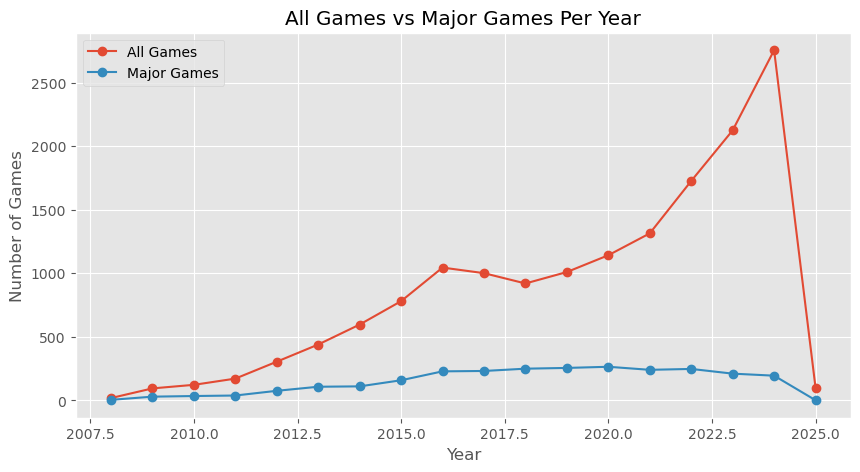

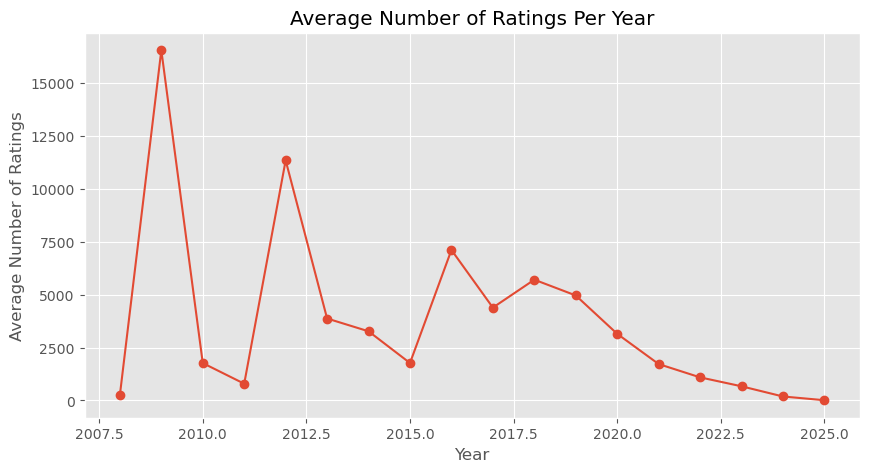

Total games: 15668
Major games(>200 ratings): 2692
Percentage of major games: 17.18%

Median number of ratings: 4.0
Mean number of ratings: 2693.51


In [17]:
# games per year comparison
games_per_year = df.groupby('Year').size()
major_per_year = major_games_df.groupby('Year').size()

plt.figure(figsize=(10, 5))
plt.plot(games_per_year.index, games_per_year.values, marker='o', label='All Games')
plt.plot(major_per_year.index, major_per_year.values, marker='o', label='Major Games')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.title('All Games vs Major Games Per Year')
plt.legend()
plt.grid(True)
plt.show()

# average number of ratings per year
avg_ratings_per_year = df.groupby('Year')['Number of Ratings'].mean()

plt.figure(figsize=(10, 5))
plt.plot(avg_ratings_per_year.index, avg_ratings_per_year.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Average Number of Ratings')
plt.title('Average Number of Ratings Per Year')
plt.grid(True)
plt.show()

# basic statistics
print(f"Total games: {len(df)}")
print(f"Major games(>200 ratings): {len(major_games_df)}")
print(f"Percentage of major games: {len(major_games_df)/len(df)*100:.2f}%")
print(f"\nMedian number of ratings: {df['Number of Ratings'].median()}")
print(f"Mean number of ratings: {df['Number of Ratings'].mean():.2f}")

**Your interpretation**:
Earlier years show more zig-zag because fewer games mean higher variability. The 200 threshold appears reasonable since the median is only 4 ratings - meaning most games have very few ratings. With 200 as the cutoff, we capture 17.18% of games as "major," filtering out low-activity games while keeping enough data for analysis.


## Task 3 Reflecting

Succinctly describe what you referenced to help you do the assignment and what the biggest challenges were.

In [18]:
# your answer goes here

References:
For this assignment, I referenced the official documentation for Python libraries including Pandas (https://pandas.pydata.org/docs/user_guide/index.html#user-guide), NumPy (https://numpy.org/doc/stable/reference/generated/numpy.log.html#numpy.log), and Matplotlib (https://matplotlib.org/stable/users/index.html). I also used lectures notebook files (07./08. lectures) understand specific functions like groupby(), describe(), and np.log10().

1. Dataset Naming Issue: Even though, it named as gaming.csv, when I checked the genres I understood it is applications in the store with mostly games and I would filter the real games based on genres. So I spent a lot of time on filtering but, after I check piazza, I had to delete my code.
2. For loop and pandas: Starting with for loop and then using pandas library were really good. Pandas library is much more faster for coding,interpreting and running. I use pandas regularly but I will try to use more often since it is working in C in the background, computation time is faster than regular python functions.
3. Popularity metric: First I multiplied rating and number of ratings but It didn't feel right and then I had to search more and find out that I should use log transformation to balance it.
4. Copy(): When I was adding new columns to filtered df, Pandas gave warnings. I learned to use .copy() when I' m creating filtered df to avoid this warning.